# 🧠 1. Introduction

Feature scaling is a crucial preprocessing step in Machine Learning.

Why?
- Algorithms like Logistic Regression, KNN, SVM depend on feature scale
- Features with large values dominate smaller ones

Two main techniques:
1. Standardization (Z-score scaling)
2. Normalization (Min-Max scaling)

# 📦 2. Import Libraries

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# 📊 3. Create Sample Dataset

In [2]:
# Create a simple dataset with different scales
data = {
    "Age": [18, 25, 30, 35, 40, 45, 50],
    "Salary": [10000, 20000, 40000, 60000, 80000, 100000, 120000]
}

df = pd.DataFrame(data)

# Display dataset
df

,Age,Salary
0,18,10000
1,25,20000
2,30,40000
3,35,60000
4,40,80000
5,45,100000
6,50,120000


# ⚖️ 4. Why Scaling is Needed

Salary values are much larger than Age → model gets biased

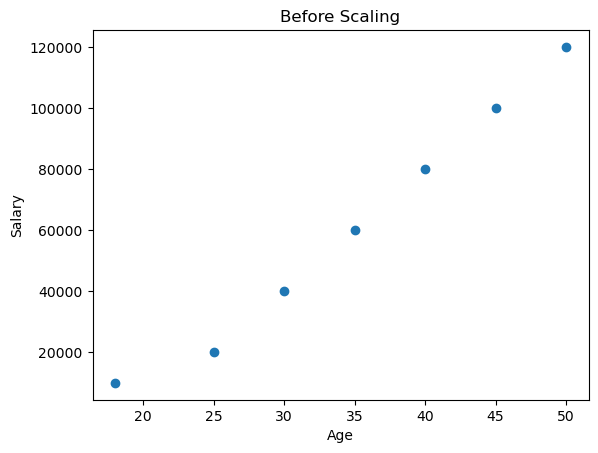

In [3]:
# Visualize feature scale difference
plt.scatter(df["Age"], df["Salary"])
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Before Scaling")
plt.show()

# 🔹 5. Standardization (Z-score Scaling)

Formula:
z = (x - μ) / σ

- Mean = 0
- Standard deviation = 1

In [4]:
# Apply StandardScaler
scaler = StandardScaler()

df_std = scaler.fit_transform(df)

# Convert back to DataFrame
df_std = pd.DataFrame(df_std, columns=df.columns)

df_std

,Age,Salary
0,-1.600489,-1.354878
1,-0.930199,-1.091429
2,-0.451420,-0.564532
3,0.027359,-0.037635
4,0.506137,0.489261
5,0.984916,1.016158
6,1.463695,1.543055


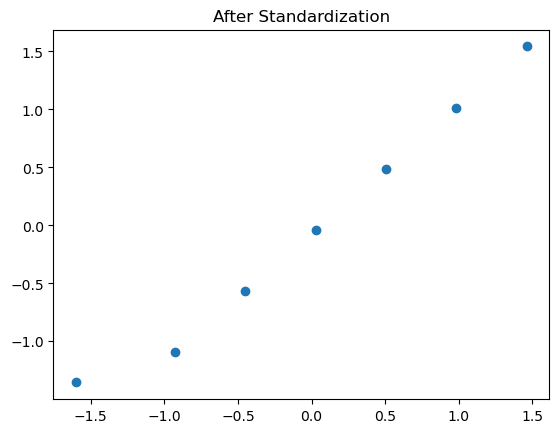

In [5]:
# Plot after standardization
plt.scatter(df_std["Age"], df_std["Salary"])
plt.title("After Standardization")
plt.show()

# 🔹 6. Normalization (Min-Max Scaling)

Formula:
x' = (x - min) / (max - min)

- Values range between 0 and 1

In [6]:
# Apply MinMaxScaler
scaler = MinMaxScaler()

df_norm = scaler.fit_transform(df)

# Convert to DataFrame
df_norm = pd.DataFrame(df_norm, columns=df.columns)

df_norm

,Age,Salary
0,0.00000,0.000000
1,0.21875,0.090909
2,0.37500,0.272727
3,0.53125,0.454545
4,0.68750,0.636364
5,0.84375,0.818182
6,1.00000,1.000000


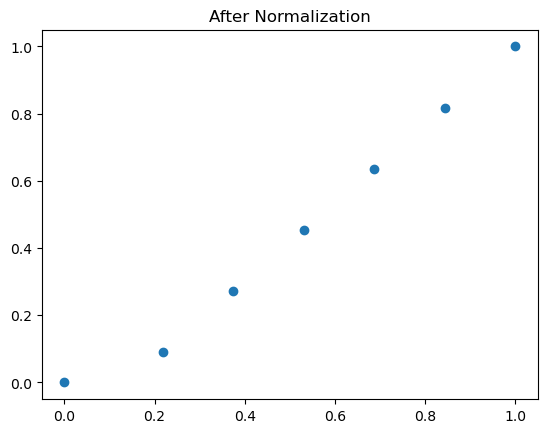

In [7]:
# Plot after normalization
plt.scatter(df_norm["Age"], df_norm["Salary"])
plt.title("After Normalization")
plt.show()

# ⚠️ 7. Important Rule (Avoid Data Leakage)

Always:
- Fit scaler only on training data
- Transform both train and test data

In [8]:
# Split dataset
X = df

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

# ⚖️ 8. Standardization vs Normalization

| Feature            | Standardization        | Normalization        |
|--------------------|------------------------|---------------------|
| Range              | (-∞, +∞)              | (0, 1)              |
| Sensitive to Outliers | Less                | More                |
| Use Case           | Most ML algorithms     | Neural Networks, KNN|

# 🎯 9. When to Use What

Use Standardization:
- Logistic Regression
- SVM
- Linear Models

Use Normalization:
- KNN
- Neural Networks

# 📌 10. Summary

- Scaling improves model performance
- Prevents feature dominance
- StandardScaler is most commonly used
- Always avoid data leakage